In [ ]:
import pickle, numpy as np, cv2, matplotlib.pyplot as plt
from pathlib import Path

HYBRIK_ROOT = Path.home() / "HybrIK"          # /home/User/HybrIK on this VM; /home/jupyter/HybrIK on the old one
RES_DANCE   = HYBRIK_ROOT / "res_dance" / "res.pk"
RES_TACKLE  = HYBRIK_ROOT / "res_tackle_01" / "res.pk"

def load_res(path):
    with open(path, "rb") as f:
        res = pickle.load(f)
    res["img_path"] = [
        str(Path(p) if Path(p).is_absolute() else HYBRIK_ROOT / p)
        for p in res["img_path"]
    ]
    res["bbox"]  = np.asarray(res["bbox"], dtype = np.float64) #(N,4) xyxy, squared crop
    res["pred_uvd"] = np.asarray(res["pred_uvd"], dtype = np.float64) #(N, 29, 3) uvd coordinates    
    return res

res = load_res(RES_DANCE)
N = len(res["img_path"]); W = int(res["width"][0]); H = int(res["height"][0])
print(N, W, H, res["img_path"][0])

bb = res["bbox"]; w = bb[:, 2] - bb[:, 0]; h = bb[:, 3] - bb[:, 1]

assert np.abs(w - h).max() < 1e-3        # crop is square (premise of 0.1)
uv = res["pred_uvd"][:, :, :2]; assert np.abs(uv).max() <= 0.5 + 1e-6
print(np.percentile(np.abs(uv), [50, 99, 100]))   # expect p99 <~ 0.4 (1.25x padding)
print(w.min(), w.max())                   # crop size range [px] -> px-scale of jitter later
assert Path(res["img_path"][0]).exists()   # raw dance frame still on disk?

# tackle_01 も同じ方法で解像度とフレーム数を確認する。
res_t = load_res(RES_TACKLE)
Nt = len(res_t["img_path"]); Wt = int(res_t["width"][0]); Ht = int(res_t["height"][0])
assert Path(res_t["img_path"][0]).exists()   # raw tackle frame still on disk?
print(f"dance: {N} frames, {W}x{H}")
print(f"tackle_01: {Nt} frames, {Wt}x{Ht}")
print("Phase 1 evaluation video: 80 frames, 3840x2160")
if (Nt, Wt, Ht) != (80, 3840, 2160):
    print("NOTE: tackle_01 and the Phase 1 evaluation video differ in frame count and/or resolution; do not treat them as identical footage.")

1198 1280 720 res_dance/raw_images/dance-000001.png
[0.12476683 0.4006247  0.46317494]
313.649658203125 648.3638916015625
dance: 1198 frames, 1280x720
tackle_01: 126 frames, 3840x2160
Phase 1 evaluation video: 80 frames, 3840x2160
NOTE: tackle_01 and the Phase 1 evaluation video differ in frame count and/or resolution; do not treat them as identical footage.


### Cell 1: Assumption Verification and Result Interpretation

This cell loads HybrIK’s `res.pk` and verifies the assumptions on which the subsequent inverse projection depends using the actual data. `w == h` confirms that the crop is square, while $|u|,|v|\le 0.5$ confirms that the predicted joints lie within the crop’s normalized range. If any of these assertions fail, recheck the data-generation conditions before proceeding with the inverse projection.

The dance output `[0.12476683, 0.40062470, 0.46317494]` represents the 50th, 99th, and 100th percentiles of $|u|,|v|$. The maximum value is also below 0.5, indicating that the network outputs remain within the crop expected from 1.25× padding. The crop width varies between approximately 313.65 and 648.36 px across frames. This $\Delta w_t$ may be a potential source of detector-box-induced jitter, which will be examined in Exercise e.

For `tackle_01`, the number of frames and resolution are also displayed and compared with the Phase 1 evaluation video’s 80 frames and 3840×2160 resolution. If they do not match, do not treat the two sequences as the same footage; explicitly note the difference in inputs when making comparisons.

In [5]:
def uvd_to_pixels(uvd, bbox):
    """
    Inverse of HybrIK's crop normalisation (see worksheet 0.1-0.2).
    uvd : (N, 29, 3)  crop-normalised (u, v, d); u, v in [-0.5, 0.5], origin = crop centre
    bbox: (N, 4)      squared crop box [x1, y1, x2, y2] in image pixels (= res['bbox'])
    returns P: (N, 29, 2) image-pixel coordinates (x right, y down)
    """
    x1, y1, x2, y2 = bbox.T
    cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    w, h = x2 - x1, y2 - y1
    p = cx[:, None] + uvd[:, :, 0] * w[:, None], cy[:, None] + uvd[:, :, 1] * h[:, None]
    return np.stack(p, axis=-1)

# --- Unit tests: they encode the CONVENTION, not the data ---
fake_uvd = np.zeros((1,29,3))
fake_bbox = np.array([[100.0, 200.0, 300.0, 400.0]])
P0 = uvd_to_pixels(fake_uvd, fake_bbox)
assert np.allclose(P0[0, 0], [200.0, 300.0])         # u = v = 0 -> crop centre (trap 1!)
fake_uvd[0, :, 0] = 0.5; fake_uvd[0, :, 1] = -0.5
P1 = uvd_to_pixels(fake_uvd, fake_bbox)
assert np.allclose(P1[0, 0], [300.0, 200.0])  # top-right corner

### Analysis of the Center-Coordinate Convention

HybrIK’s $u,v$ coordinates use the crop center as the origin, so the correct inverse transformation is $p_x=c_x+w u$, $p_y=c_y+h v$. If they are mistakenly treated as top-left coordinates and calculated as $p_x=x_1+w u$, $p_y=y_1+h v$, then $u=v=0$ maps to the top-left corner $(x_1,y_1)$ instead of the crop center. In the test above, this produces $(100,200)$ instead of the correct $(200,300)$, resulting in an x- and y-offset of $-100$ px.

Therefore, for a 400 px square crop, every joint is shifted **200 px left in x and 200 px upward in y**. The two-dimensional displacement is $\sqrt{200^2+200^2}\approx 282.8$ px. This uniform half-box displacement is a diagnostic pattern indicating that the coordinate-origin convention has been misinterpreted.

AssertionError: Image at res_dance/raw_images/dance-000001.png not found

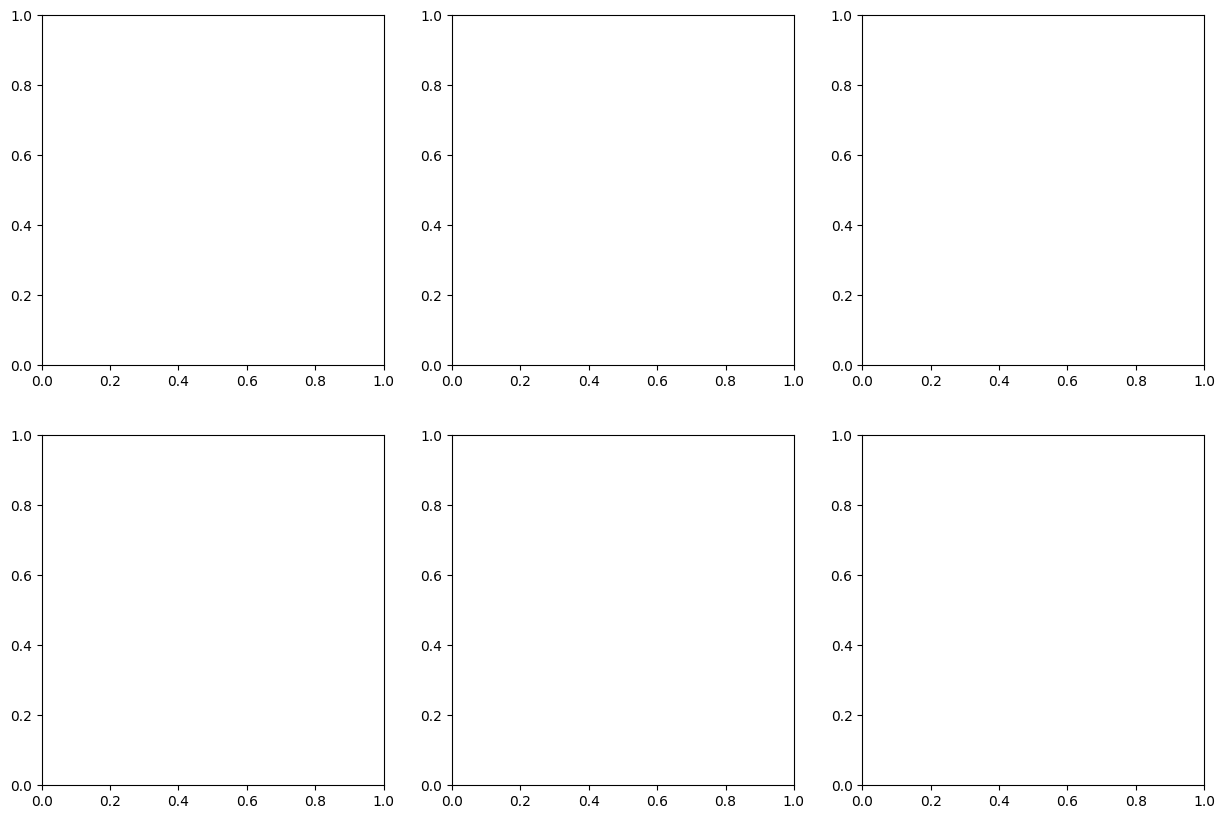

In [6]:
# SMPL-24 index -> COCO body-12 order (L/R shoulder, elbow, wrist, hip, knee, ankle)
SMPL_TO_BODY12 = [16,17,18,19,20,21,1,2,4,5,7,8]
BODY12_NAMES = ["L_sho","R_sho","L_elb","R_elb","L_wri","R_wri","L_hip","R_hip","L_kne","R_kne","L_ank","R_ank"]
COCO_IDX_BODY12 = [5,6,7,8,9,10,11,12,13,14,15,16] #same joints in COCO-17 numbering
# skeleton edges for body-12 indexing
EDGES12 = [(0, 2), (2, 4), (1, 3), (3, 5), (6, 8), (8, 10), (7, 9), (9, 11),(0,1),(6,7),(0,6),(1,7)]

def draw_pose(img_bgr, pts12, bbox=None, color=(0, 255, 0)):
    """Draw body-12 edges, red joints, and an optional blue bbox in place."""
    pts12 = np.asarray(pts12, dtype=np.float64)
    if pts12.shape != (12, 2):
        raise ValueError(f"Expected pts12 shape (12, 2), got {pts12.shape}")

    for a, b in EDGES12:
        pt_a = tuple(np.rint(pts12[a]).astype(int))
        pt_b = tuple(np.rint(pts12[b]).astype(int))
        cv2.line(img_bgr, pt_a, pt_b, color, 2)
    for x, y in pts12:
        cv2.circle(img_bgr, (int(round(x)), int(round(y))), 4, (0, 0, 255), -1)
    if bbox is not None:
        x1, y1, x2, y2 = np.rint(bbox).astype(int)
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (255, 0, 0), 1)
    return img_bgr

P = uvd_to_pixels(res["pred_uvd"], res["bbox"])
P12 = P[:, SMPL_TO_BODY12, :]

frames_to_check = [0,300,600,900,1045,N-1] # 1045 = inside the beta-spike window (deep crouch, Phase A ex. e)

fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax,t in zip(axes.ravel(), frames_to_check):
    img = cv2.imread(str(Path(res["img_path"][t])))  # BGR; None if the path is wrong
    assert img is not None, f"Image at {res['img_path'][t]} not found"
    img = draw_pose(img, P12[t], res["bbox"][t])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(f"dance frame {t}"); ax.axis("off")
plt.tight_layout(); plt.savefig("fig_b1_overlay_dance.png", dpi=120); plt.show()

### Cell 3: Visualising the 12-joint pose

This cell selects 12 body joints from HybrIK's 29-joint output and converts their coordinates into image-pixel positions. It connects related joints to draw a simple skeleton, marks the joints and bounding box on the original image, and displays selected frames for visual inspection. This helps verify that the coordinate conversion and joint mapping are correct before calculating jitter.

In [ ]:
P1_COORD_MODE = "xyn"

def to_phase1_coords(P, W, H, mode=P1_COORD_MODE):
    if mode == "xyn":
        P1 = P.copy()
        P1[..., 0] /= W
        P1[..., 1] /= H
        return P1
    if mode == "pixel":
        return P.copy()
    raise ValueError(f"Unsupported mode: {mode}")
    
def displacement_series(P):
    """P: (T, K, 2) -> d: (T-1, K), d[t-1, k] = ||P[t, k] - P[t-1, k]||_2 for t = 1..T-1"""
    return np.linalg.norm(P[1:] - P[:-1], axis=-1)

def jitter_JK(P):
    """Phase-1 Eq.(3): J_k = mean_t d_k(t). Returns (K,)"""
    d = displacement_series(P)
    return d.mean(axis=0)

Pn      = to_phase1_coords(P12, W, H)
d_dance = displacement_series(Pn)            # (N-1, 12)
Jk_dance = jitter_JK(Pn)
def print_jitter_table(coords, unit_name):
    """
    coords: (T, 12, 2)
    unit_name: name of the displayed coordinate unit
    """
    d = displacement_series(coords)
    jk = d.mean(axis=0)
    median_d = np.median(d, axis=0)
    p99_d = np.percentile(d, 99, axis=0)
    max_d = d.max(axis=0)

    print(f"joint       Jk ({unit_name})   median       p99          max")
    print("-" * 68)

    for name, jk_value, median_value, p99_value, max_value in zip(
        BODY12_NAMES, jk, median_d, p99_d, max_d
    ):
        print(
            f"{name:<10} "
            f"{jk_value:>12.5f} "
            f"{median_value:>12.5f} "
            f"{p99_value:>12.5f} "
            f"{max_value:>12.5f}"
        )

    return {
        "d": d,
        "Jk": jk,
        "median": median_d,
        "p99": p99_d,
        "max": max_d,
    }


# Use the same coordinate units as Phase 1: (x/W, y/H)
print("=== Dance: Phase 1 coordinate units (x/W, y/H) ===")
dance_xyn_stats = print_jitter_table(Pn, "xyn")

print()

# Also report pixel units for interpretation: px/frame
print("=== Dance: pixel units (px/frame) ===")
dance_pixel_stats = print_jitter_table(P12, "px/frame")

=== Dance: Phase 1 coordinate units (x/W, y/H) ===
joint       Jk (xyn)   median       p99          max
--------------------------------------------------------------------
L_sho           0.00380      0.00282      0.01546      0.02146
R_sho           0.00414      0.00320      0.01665      0.03504
L_elb           0.00803      0.00627      0.03551      0.05966
R_elb           0.00856      0.00621      0.04238      0.11495
L_wri           0.01243      0.00849      0.06839      0.10529
R_wri           0.01315      0.00835      0.07323      0.19840
L_hip           0.00318      0.00233      0.01367      0.01699
R_hip           0.00304      0.00214      0.01270      0.01669
L_kne           0.00332      0.00186      0.02107      0.06784
R_kne           0.00264      0.00183      0.01221      0.01677
L_ank           0.00283      0.00090      0.02935      0.05130
R_ank           0.00206      0.00087      0.01689      0.02666

=== Dance: pixel units (px/frame) ===
joint       Jk (px/frame)   medi

### Cell 4: Computing frame-to-frame jitter

This cell uses the joint coordinates obtained in Cell 3 to calculate how far each joint moves between adjacent frames and summarises the result as jitter.

#### 1. Coordinate-unit selection

`P1_COORD_MODE = "xyn"` specifies that the main calculation uses the same normalised coordinates as Phase 1. With `xyn`, image pixel coordinates are divided by the image width and height.

$$
x_{norm} = \frac{x_{px}}{W}, \qquad y_{norm} = \frac{y_{px}}{H}
$$

For example, if the image width is `1920 px` and the x-coordinate is `960 px`, the normalised x-coordinate is `0.5`. This makes it easier to compare relative movement across videos with different resolutions. If `pixel` is specified, the original pixel coordinates are used without conversion.

`P.copy()` is used so that the original array is not modified. If `P` itself were changed during normalisation, later pixel-unit calculations would also use the normalised values.

#### 2. Frame-to-frame displacement

`displacement_series(P)` calculates the distance between the same joint in adjacent frames. The shape of `P` is `(T, K, 2)`.

- `T`: number of frames
- `K`: number of joints, here 12
- `2`: x and y coordinates

`P[1:] - P[:-1]` creates the following differences in one operation:

```text
P[1] - P[0]
P[2] - P[1]
P[3] - P[2]
...
```

Therefore, there are `T-1` frame transitions, and the difference array has shape `(T-1, K, 2)`. For the final dimension `[dx, dy]`, the code calculates the Euclidean distance:

$$
d_k(t) = \sqrt{\left(x_k(t)-x_k(t-1)\right)^2 + \left(y_k(t)-y_k(t-1)\right)^2}
$$

In `np.linalg.norm(..., axis=-1)`, `axis=-1` means that the final dimension containing the x and y components is converted into one distance value. The output `d` has shape `(T-1, K)`, and each value represents how far one joint moved during one frame transition.

#### 3. Per-joint Jk

`jitter_JK(P)` calculates the mean movement across all frame transitions for each joint.

$$
J_k = \frac{1}{T-1}\sum_{t=1}^{T-1} d_k(t)
$$

In `d.mean(axis=0)`, `axis=0` means that the time dimension is averaged. The result is an array of shape `(K,)` containing one value per joint. A larger Jk means that a joint has larger frame-to-frame variation over the video. However, Jk includes both genuine human movement and pose-estimation fluctuation, so it should not be interpreted as estimation error alone.

#### 4. Preparing the dance sequence

```python
Pn = to_phase1_coords(P12, W, H)
```

This converts the 12-joint pixel coordinates `P12` from Cell 3 into the normalised coordinates used in Phase 1. `d_dance` stores the frame-to-frame displacement for the dance video, while `Jk_dance` stores the mean displacement for each joint.

#### 5. Summary table

`print_jitter_table()` displays four statistics for each joint.

- `Jk`: mean displacement; sensitive to large outliers
- `median`: the typical frame-to-frame displacement; relatively robust to outliers
- `p99`: the 99th percentile; indicates how large the strongest non-extreme jumps are
- `max`: the largest displacement; represents the single most extreme jump

If the mean and median are close, the movement may be relatively consistent. If the mean is much larger than the median, some frames may contain unusually large jumps. In that case, inspect `p99`, `max`, and the overlay images from Cell 3 together.

The function does not only print the table; it also returns a dictionary containing `d`, `Jk`, `median`, `p99`, and `max`. This allows later cells to analyse particular joints or frames in more detail.

#### 6. Reporting two units

The first table uses `xyn` units and is intended for comparison with Phase 1. The second table uses `px/frame` units and shows how many pixels a joint actually moves in the image. Either unit can be used for comparing joints within the same video, but normalised `xyn` units are more appropriate for the main comparison across videos with different resolutions.

This cell does not measure pure noise in the strict sense. It measures **frame-to-frame variation that includes actual movement, changes in the detection box, pose-estimation fluctuation, and image noise**. Therefore, Jk should be interpreted together with PCK, MPJPE, overlay images, the median, and outlier information.

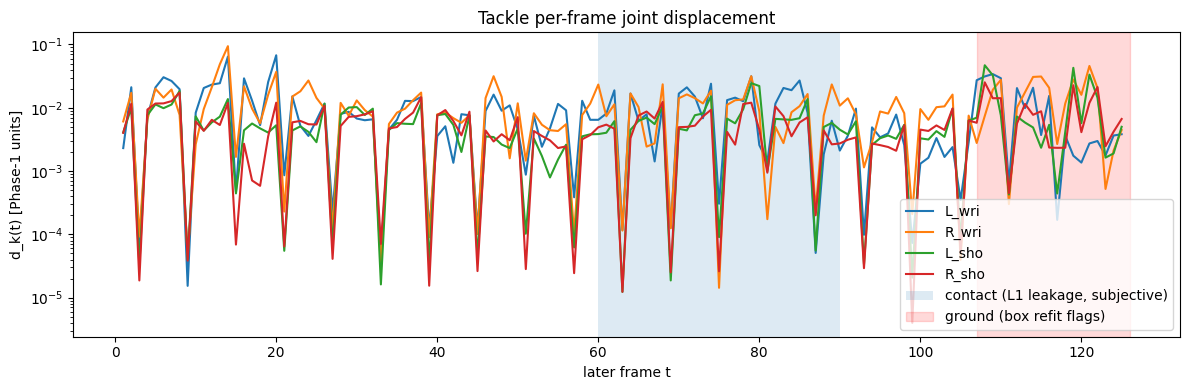

=== Tackle: robust Jk summary (Phase-1 units) ===
joint       Jk(mean)    median      Jk_trim   n_out   outlier frames
------------------------------------------------------------------------------
L_sho         0.00646    0.00497    0.00498     4   108, 109, 119, 121
R_sho         0.00574    0.00492    0.00498     1   108
L_elb         0.00730    0.00550    0.00609     3   14, 108, 109
R_elb         0.00788    0.00587    0.00632     4   14, 20, 119, 121
L_wri         0.01016    0.00658    0.00832     3   14, 20, 109
R_wri         0.01175    0.00953    0.00974     2   13, 14
L_hip         0.00480    0.00435    0.00419     0   -
R_hip         0.00501    0.00431    0.00436     0   -
L_kne         0.00707    0.00479    0.00596     6   14, 20, 22, 23, 74, 121
R_kne         0.00758    0.00562    0.00614     4   23, 32, 108, 109
L_ank         0.01041    0.00775    0.00869     1   26
R_ank         0.01007    0.00651    0.00824     4   17, 32, 108, 122

Trimmed frames per joint: 7

=== Dance v

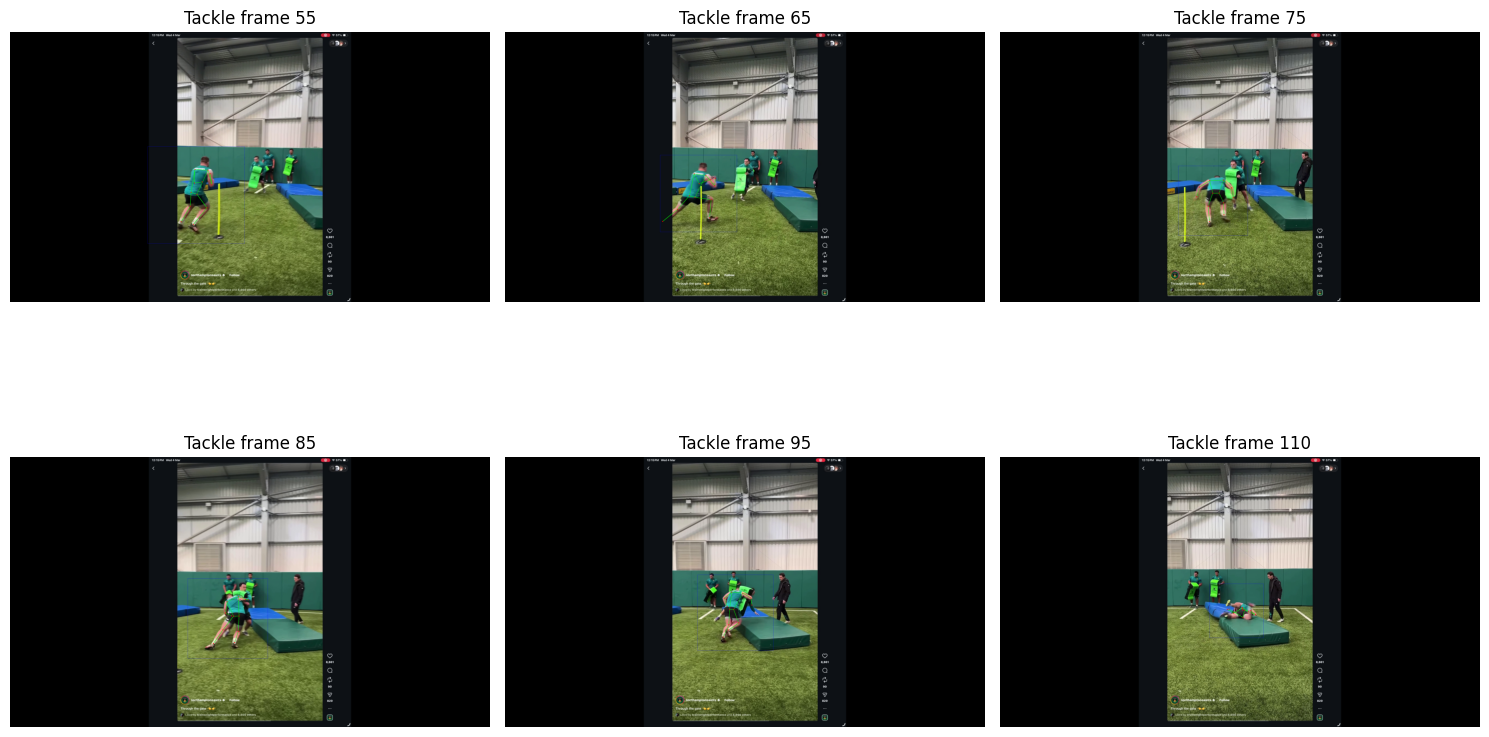

In [ ]:
res_t = load_res(RES_TACKLE)
Wt, Ht = int(res_t["width"][0]), int(res_t["height"][0])
Pt = uvd_to_pixels(res_t["pred_uvd"], res_t["bbox"])[:, SMPL_TO_BODY12, :]
Pn_t = to_phase1_coords(Pt, Wt, Ht)
d_t = displacement_series(Pn_t)  # d_t[t-1] is the displacement into original frame t

# (1) Per-frame diagnostic with Phase-A windows shaded.
# The x-axis is the later frame in each pair: frame 1, ..., frame N-1.
fig, ax = plt.subplots(figsize=(12, 4))
for k in [4, 5, 0, 1]:  # wrists and shoulders first (arm-wrap joints, K5)
    ax.plot(
        np.arange(1, len(d_t) + 1),
        d_t[:, k],
        label=BODY12_NAMES[k],
    )
ax.axvspan(60, 90, alpha=0.15, label="contact (L1 leakage, subjective)")
ax.axvspan(107, 126, alpha=0.15, color="r", label="ground (box refit flags)")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("later frame t")
ax.set_ylabel("d_k(t) [Phase-1 units]")
ax.set_title("Tackle per-frame joint displacement")
plt.tight_layout()
plt.savefig("fig_b1_dkt_tackle.png", dpi=120)
plt.show()

# (2) Robust summary: quantify how much of mean Jk is carried by outliers.
def summarize_displacement(d, names, trim_fraction=0.05):
    """Return per-joint Jk, median, trimmed Jk, outlier count, and frame IDs."""
    median_d = np.median(d, axis=0)
    threshold = 5.0 * median_d
    outlier_mask = d > threshold
    n_out = outlier_mask.sum(axis=0)
    out_frames = {
        names[k]: (np.flatnonzero(outlier_mask[:, k]) + 1).tolist()
        for k in range(d.shape[1])
    }

    n_keep = max(1, int(np.floor(d.shape[0] * (1.0 - trim_fraction))))
    sorted_d = np.sort(d, axis=0)
    jk_trim = sorted_d[:n_keep].mean(axis=0)

    return {
        "Jk": d.mean(axis=0),
        "median": median_d,
        "Jk_trim": jk_trim,
        "n_out": n_out,
        "out_frames": out_frames,
        "threshold": threshold,
        "n_trimmed": d.shape[0] - n_keep,
    }


def print_tackle_summary(stats, names):
    print("joint       Jk(mean)    median      Jk_trim   n_out   outlier frames")
    print("-" * 78)
    for k, name in enumerate(names):
        frames = ", ".join(map(str, stats["out_frames"][name])) or "-"
        print(
            f"{name:<10} "
            f"{stats['Jk'][k]:>10.5f} "
            f"{stats['median'][k]:>10.5f} "
            f"{stats['Jk_trim'][k]:>10.5f} "
            f"{stats['n_out'][k]:>5d}   "
            f"{frames}"
        )
    print(f"\nTrimmed frames per joint: {stats['n_trimmed']}")


tackle_stats = summarize_displacement(d_t, BODY12_NAMES)
print("=== Tackle: robust Jk summary (Phase-1 units) ===")
print_tackle_summary(tackle_stats, BODY12_NAMES)

# (3) DoD3 comparison table.
# Absolute Jk mixes true motion and estimation jitter; use this table for diagnosis,
# not as a standalone ranking between the different clips.
dance_stats = summarize_displacement(d_dance, BODY12_NAMES)
print("\n=== Dance vs tackle: Jk summary (Phase-1 units) ===")
print("joint       dance Jk   tackle Jk   dance med  tackle med  tackle n_out")
print("-" * 73)
for k, name in enumerate(BODY12_NAMES):
    print(
        f"{name:<10} "
        f"{dance_stats['Jk'][k]:>9.5f} "
        f"{tackle_stats['Jk'][k]:>10.5f} "
        f"{dance_stats['median'][k]:>10.5f} "
        f"{tackle_stats['median'][k]:>11.5f} "
        f"{tackle_stats['n_out'][k]:>11d}"
    )

# (4) Overlay selected tackle frames.
frames_tackle = [55, 65, 75, 85, 95, 110]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, t in zip(axes.ravel(), frames_tackle):
    image_path = Path(res_t["img_path"][t])
    img = cv2.imread(str(image_path))
    assert img is not None, f"Image at {image_path} not found"
    img = draw_pose(img, Pt[t], res_t["bbox"][t])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Tackle frame {t}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("fig_b1_overlay_tackle.png", dpi=120)
plt.show()

### Cell 5: Summary and interpretation of the tackle results

This cell analyses frame-to-frame displacement in the tackle sequence. It combines a per-frame diagnostic plot, robust statistics, a comparison with the dance sequence, and visual overlays of selected tackle frames. The purpose is to determine whether large Jk values reflect continuous movement, a small number of unstable frames, or possible effects from occlusion and bounding-box changes.

#### Interpreting the reported values

- **Jk (mean)**: The average frame-to-frame displacement for a joint. A larger value means that the joint changes position more strongly on average. However, Jk includes genuine player movement as well as pose-estimation fluctuation, detection-box movement, and image noise.
- **Median**: The typical frame-to-frame displacement. It is less affected by a few extreme jumps than the mean.
- **Jk_trim**: The mean after removing the largest 5% of displacement values. If Jk is much larger than Jk_trim, a small number of large jumps is strongly influencing the ordinary mean.
- **n_out**: The number of displacement values that exceed five times the joint's median displacement. This is a diagnostic rule, not proof that those frames are incorrect.
- **outlier frames**: The frame numbers where the displacement exceeds that threshold. These frames should be checked against the plot and the overlay images.

#### How to read the results

1. If **Jk and the median are both large**, the joint may be moving continuously during the tackle, or the joint estimate may be unstable throughout the sequence.
2. If **Jk is large but the median is small**, the mean is probably being driven by a few sudden jumps. Compare Jk with Jk_trim and inspect the listed outlier frames.
3. If **Jk_trim is close to Jk**, large displacements are spread across much of the sequence rather than being caused by only a few outliers.
4. If **n_out is high**, the joint has repeated unusually large frame-to-frame changes. This may indicate severe occlusion, identity or bounding-box changes, or genuinely rapid movement.
5. If the displacement spike occurs inside the shaded contact or ground interval, the event may be related to the tackle itself or to a tracking/refitting change. The shaded interval provides context but does not prove the cause.

#### Dance-versus-tackle comparison

The comparison table shows the mean and median displacement for each joint in both sequences. A larger tackle value indicates greater frame-to-frame variation in that clip, but it does not automatically mean that tackle pose estimation is worse. Dance and tackle contain different types and amounts of real motion, so Jk should be used for diagnosis rather than as a standalone ranking between clips.

A useful pattern is:

- **Tackle mean and median both higher**: the tackle sequence has stronger overall movement or variation for that joint.
- **Tackle mean higher but median similar**: the difference may be concentrated in a few tackle frames.
- **Tackle n_out higher**: the tackle sequence contains more abrupt changes that require visual inspection.

#### Role of the overlay images

The selected-frame overlays help distinguish among three possibilities:

- a real and plausible rapid movement,
- a pose-estimation jump caused by occlusion,
- a coordinate or bounding-box problem.

Therefore, an outlier should not be removed automatically. First check whether the joint location, skeleton, and bounding box are visually plausible. The final interpretation should combine the numerical table, the per-frame plot, and the overlay images.

f1 raw-vs-uvd max error: 0.000105 px
=== Dance: raw vs struct reprojection residual ===
joint       median px   p95 px    max px    median %w   p95 %w    max %w
------------------------------------------------------------------------------
L_sho           3.314    10.549    15.723      0.644     2.225     3.557
R_sho           4.529    10.485    16.746      0.902     2.210     3.599
L_elb           4.843    11.361    33.169      0.948     2.276     6.320
R_elb           4.976    12.675    44.368      0.963     2.573     9.133
L_wri           9.250    22.764    46.980      1.780     4.721     9.010
R_wri           9.708    30.452    59.628      1.913     6.510    12.011
L_hip           1.082     2.958     7.920      0.217     0.613     1.577
R_hip           1.110     2.619     3.640      0.219     0.570     0.994
L_kne           3.440     7.970    41.306      0.693     1.562     8.134
R_kne           2.709     8.784    13.209      0.522     1.945     3.287
L_ank           4.142     9.98

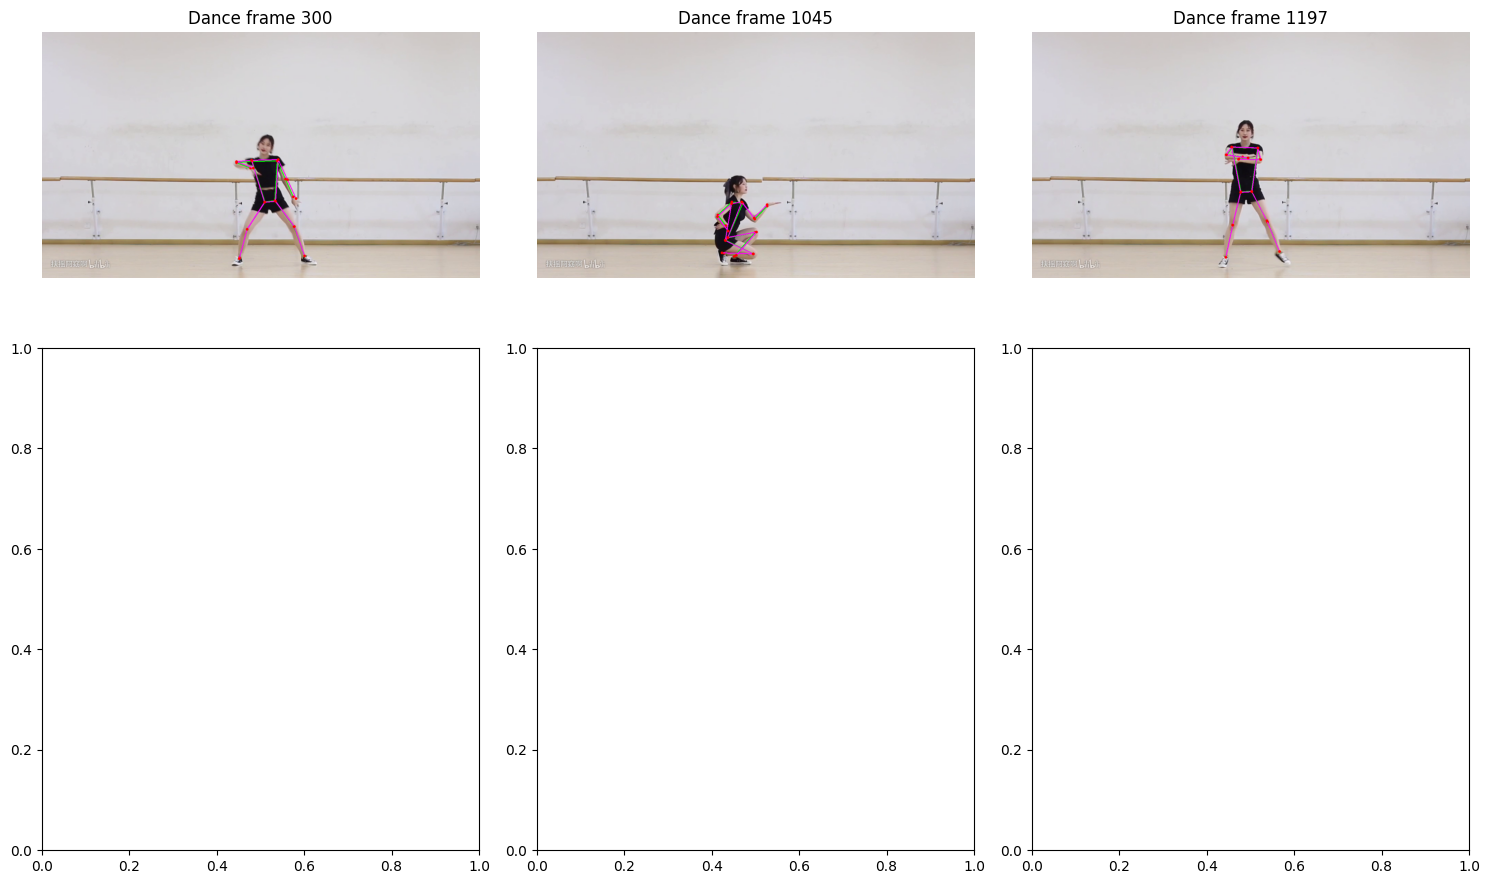


=== Tackle: raw vs struct reprojection residual ===
joint       median px   p95 px    max px    median %w   p95 %w    max %w
------------------------------------------------------------------------------
L_sho          10.823    21.704    35.941      1.653     4.471    10.134
R_sho          11.508    26.274    50.703      1.427     4.366     7.952
L_elb          12.173    24.700    32.767      1.545     5.219     9.239
R_elb          15.719    29.695    53.138      2.025     5.337    12.489
L_wri          14.087    33.562    51.022      1.835     7.468    12.744
R_wri          19.711    50.454    59.472      2.828     6.939    16.480
L_hip           4.152     7.856     9.881      0.584     1.403     2.975
R_hip           3.226     6.942    21.954      0.483     1.416     6.610
L_kne           5.785    26.277    55.409      0.800     6.541    12.686
R_kne           5.918    33.026    56.250      0.829     7.850    12.878
L_ank          18.455    70.961   111.635      2.275    18.238   

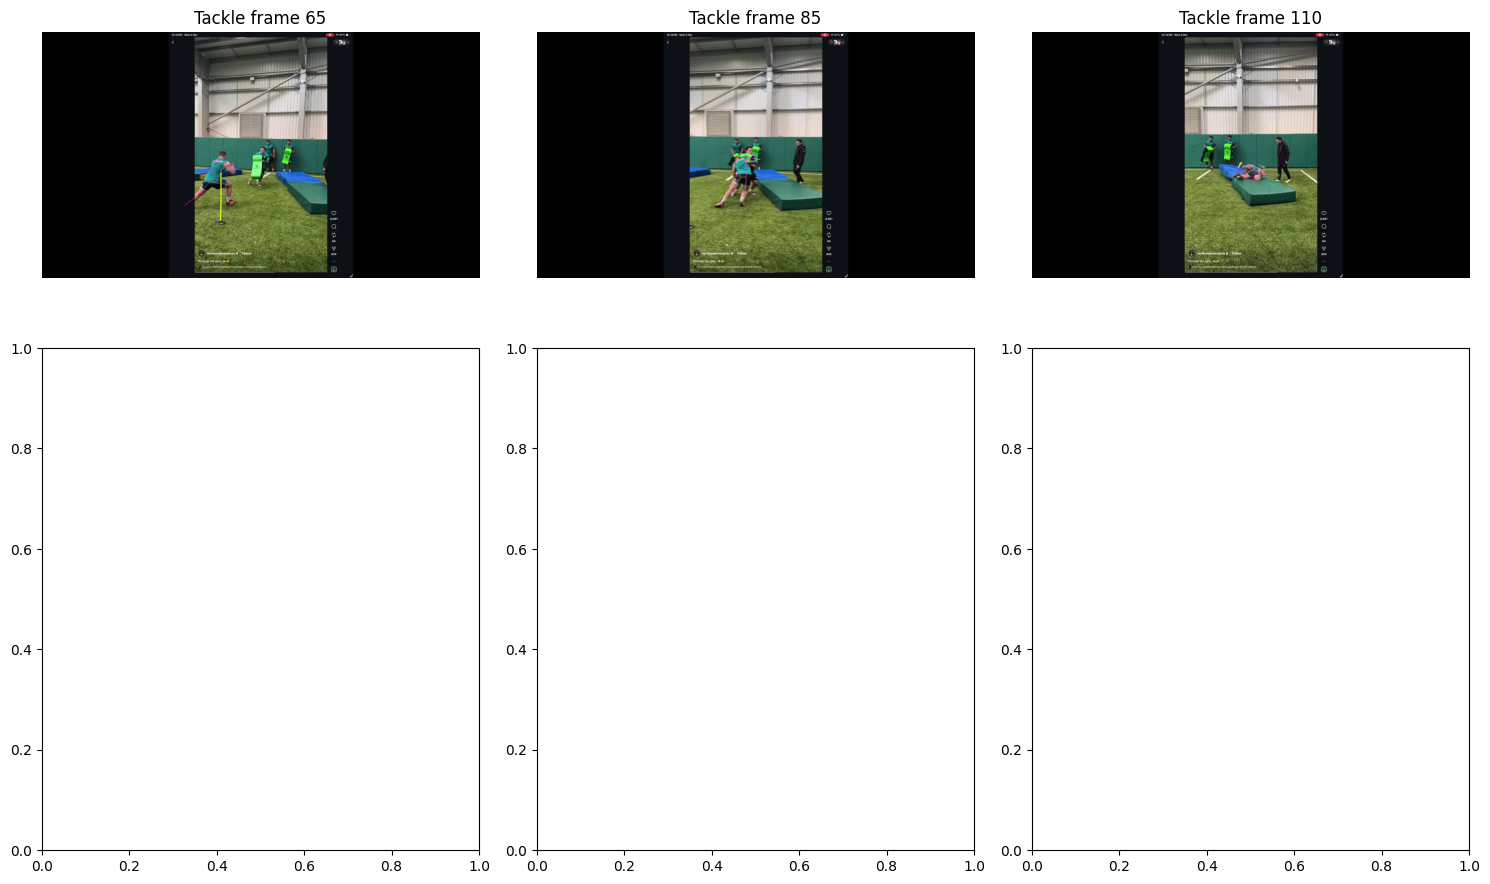

In [ ]:
#F
F_CROP, INP = 1000.0, 256.0
DEPTH_FACTOR = 2.2


def project_cam_to_pixels(X_abs, bbox, W, H):
    """Project camera-frame metres to image pixels with HybrIK's crop camera."""
    X_abs = np.asarray(X_abs, dtype=np.float64)
    bbox = np.asarray(bbox, dtype=np.float64)
    w = bbox[:, 2] - bbox[:, 0]
    if X_abs.ndim != 3 or X_abs.shape[0] != len(bbox) or X_abs.shape[-1] != 3:
        raise ValueError(f"Expected X_abs (N, J, 3), got {X_abs.shape}")
    if np.any(X_abs[..., 2] <= 0):
        raise ValueError("All camera-frame depths must be positive before projection")

    f_img = F_CROP * w / INP
    x = W / 2.0 + f_img[:, None] * X_abs[..., 0] / X_abs[..., 2]
    y = H / 2.0 + f_img[:, None] * X_abs[..., 1] / X_abs[..., 2]
    return np.stack([x, y], axis=-1)


def body12_from_24(points):
    """Select the body-12 joints from an (N, 24, ...) SMPL array."""
    return points[:, SMPL_TO_BODY12, ...]


def print_struct_residual_table(resid_px, bbox, names):
    """Print raw-vs-struct residuals in pixels and as a percentage of crop width."""
    crop_width = np.asarray(bbox, dtype=np.float64)[:, 2] - np.asarray(bbox, dtype=np.float64)[:, 0]
    resid_pct = resid_px / crop_width[:, None] * 100.0

    print("joint       median px   p95 px    max px    median %w   p95 %w    max %w")
    print("-" * 78)
    for k, name in enumerate(names):
        px_values = resid_px[:, k]
        pct_values = resid_pct[:, k]
        print(
            f"{name:<10} "
            f"{np.median(px_values):>10.3f} "
            f"{np.percentile(px_values, 95):>9.3f} "
            f"{np.max(px_values):>9.3f} "
            f"{np.median(pct_values):>10.3f} "
            f"{np.percentile(pct_values, 95):>9.3f} "
            f"{np.max(pct_values):>9.3f}"
        )

    return resid_pct


def overlay_raw_struct(res_data, raw12, struct12, frames, output_path, title_prefix):
    """Overlay raw joints in green and struct joints in magenta."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, t in zip(axes.ravel(), frames):
        image_path = Path(res_data["img_path"][t])
        img = cv2.imread(str(image_path))
        assert img is not None, f"Image at {image_path} not found"

        # Draw the bbox once, then the two pose estimates in distinct colors.
        img = draw_pose(img, raw12[t], color=(0, 255, 0))
        img = draw_pose(img, struct12[t], color=(255, 0, 255))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{title_prefix} frame {t}")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(output_path, dpi=120)
    plt.show()


# f1: exact identity. The raw heatmap joints use pred_cam_root, not transl.
# This should reproduce the uvd path from exercise A up to numerical tolerance.
cam_root = np.asarray(res["pred_cam_root"], dtype=np.float64)
transl = np.asarray(res["transl"], dtype=np.float64)
X_raw = np.asarray(res["pred_xyz_29"], dtype=np.float64) * DEPTH_FACTOR + cam_root[:, None, :]
P_raw = project_cam_to_pixels(X_raw, res["bbox"], W, H)
raw_identity_error = np.abs(P_raw - P).max()
print(f"f1 raw-vs-uvd max error: {raw_identity_error:.6f} px")
assert raw_identity_error < 0.5, f"Raw projection mismatch: {raw_identity_error:.6f} px"

# f2: struct joints are camera-frame joints after SMPL reconstruction.
X_struct = (
    np.asarray(res["pred_xyz_24_struct"], dtype=np.float64) * DEPTH_FACTOR
    + transl[:, None, :]
)
P_struct = project_cam_to_pixels(X_struct, res["bbox"], W, H)
P_raw12 = P_raw[:, SMPL_TO_BODY12, :]
P_struct12 = body12_from_24(P_struct)
resid = np.linalg.norm(P_struct12 - P_raw12, axis=-1)

print("=== Dance: raw vs struct reprojection residual ===")
resid_pct = print_struct_residual_table(resid, res["bbox"], BODY12_NAMES)

# Overlay raw (green) and struct (magenta) on the dance sequence.
overlay_raw_struct(
    res,
    P_raw12,
    P_struct12,
    [300, 1045, N - 1],
    "fig_b1_overlay_raw_struct_dance.png",
    "Dance",
)

# Repeat the same analysis for tackle frames required by the worksheet.
res_t = load_res(RES_TACKLE)
Wt, Ht = int(res_t["width"][0]), int(res_t["height"][0])
cam_root_t = np.asarray(res_t["pred_cam_root"], dtype=np.float64)
transl_t = np.asarray(res_t["transl"], dtype=np.float64)
X_raw_t = np.asarray(res_t["pred_xyz_29"], dtype=np.float64) * DEPTH_FACTOR + cam_root_t[:, None, :]
P_raw_t = project_cam_to_pixels(X_raw_t, res_t["bbox"], Wt, Ht)
X_struct_t = (
    np.asarray(res_t["pred_xyz_24_struct"], dtype=np.float64) * DEPTH_FACTOR
    + transl_t[:, None, :]
)
P_struct_t = project_cam_to_pixels(X_struct_t, res_t["bbox"], Wt, Ht)
P_raw12_t = P_raw_t[:, SMPL_TO_BODY12, :]
P_struct12_t = body12_from_24(P_struct_t)
resid_t = np.linalg.norm(P_struct12_t - P_raw12_t, axis=-1)

print("\n=== Tackle: raw vs struct reprojection residual ===")
resid_pct_t = print_struct_residual_table(resid_t, res_t["bbox"], BODY12_NAMES)
overlay_raw_struct(
    res_t,
    P_raw12_t,
    P_struct12_t,
    [65, 85, 110],
    "fig_b1_overlay_raw_struct_tackle.png",
    "Tackle",
)

In [ ]:
import numpy as np
from pathlib import Path
OUT_DIR = Path.home() / "data/phase2_npz"; OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_sheet(path, coords_norm, confs, fps, W, H, source):
    """Save one 'answer sheet' in the common format (coords already in x/W, y/H units)."""
    assert coords_norm.shape[1:] == (12, 2) and confs.shape == coords_norm.shape[:2]
    np.savez(path, coords=coords_norm.astype(np.float32), confs=confs.astype(np.float32),
             fps=float(fps), W=int(W), H=int(H),
             joint_names=np.array(BODY12_NAMES), source=source)

# Prepare confidence scores and select the same body-12 joints as the coordinates.
def body12_confidence(res_data):
    scores = np.asarray(res_data["pred_scores"])
    scores = np.squeeze(scores)
    if scores.ndim != 2:
        raise ValueError(f"Expected confidence scores with shape (N, 29), got {scores.shape}")
    if scores.shape[1] <= max(SMPL_TO_BODY12):
        raise ValueError(f"Expected at least 29 joint scores, got {scores.shape}")
    return scores[:, SMPL_TO_BODY12]

confs_t = body12_confidence(res_t)
confs_dance = body12_confidence(res)

# Save raw and structurally reconstructed coordinates for both sequences.
save_sheet(
    OUT_DIR / "hybrik_uvd_tackle_01.npz",
    to_phase1_coords(Pt, Wt, Ht),
    confs_t,
    30,
    Wt,
    Ht,
    "hybrik_uvd",
)
save_sheet(
    OUT_DIR / "hybrik_struct_tackle_01.npz",
    to_phase1_coords(P_struct12_t, Wt, Ht),
    confs_t,
    30,
    Wt,
    Ht,
    "hybrik_struct",
)
save_sheet(
    OUT_DIR / "hybrik_uvd_dance.npz",
    to_phase1_coords(P12, W, H),
    confs_dance,
    30,
    W,
    H,
    "hybrik_uvd",
)
save_sheet(
    OUT_DIR / "hybrik_struct_dance.npz",
    to_phase1_coords(P_struct12, W, H),
    confs_dance,
    30,
    W,
    H,
    "hybrik_struct",
)

print(f"Saved four NPZ sheets to: {OUT_DIR}")

Saved four NPZ sheets to: /home/User/data/phase2_npz
